In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
orders = pd.read_csv("/content/olist_orders_dataset.csv",
                     parse_dates=["order_purchase_timestamp",
                                  "order_approved_at",
                                  "order_delivered_carrier_date",
                                  "order_delivered_customer_date",
                                  "order_estimated_delivery_date"])

reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv",
                      parse_dates=["review_creation_date",
                                   "review_answer_timestamp"])
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'olist_customers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_orders_dataset.csv', 'drive', 'sample_data']


In [ ]:
print("Shapes after loading:")
print(f"  orders    : {orders.shape}")
print(f"  reviews   : {reviews.shape}")
print(f"  payments  : {payments.shape}")
print(f"  customers : {customers.shape}")

Shapes after loading:
  orders    : (99441, 8)
  reviews   : (99224, 7)
  payments  : (103886, 5)
  customers : (99441, 5)


In [ ]:
reviews_clean = (reviews
                 .sort_values("review_creation_date")
                 .drop_duplicates(subset="order_id", keep="last")
                 [["order_id", "review_score"]])

df = pd.merge(orders, reviews_clean, on="order_id", how="left")
print(f"\nAfter orders ← reviews  : {df.shape}")


After orders ← reviews  : (99441, 9)


In [ ]:
pay_agg = (payments
           .groupby("order_id")
           .agg(
               total_payment=("payment_value", "sum"),
               payment_type=("payment_type", lambda x: x.mode()[0])
           )
           .reset_index())
df = pd.merge(df, pay_agg, on="order_id", how="left")
print(f"After df ← payments merge     : {df.shape}")

After df ← payments merge     : (99441, 11)


In [ ]:
df = pd.merge(df,
              customers[["customer_id", "customer_state"]],
              on="customer_id", how="left")
print(f"After df ← customers merge    : {df.shape}")

After df ← customers merge    : (99441, 12)


In [ ]:
df["delivery_days"] = (
    (df["order_delivered_customer_date"] -
     df["order_purchase_timestamp"]).dt.days
)

df["delay_days"] = (
    (df["order_delivered_customer_date"] -
     df["order_estimated_delivery_date"]).dt.days
)

df["is_late"] = (df["delay_days"] > 0).astype(int)

print("\nFeature engineering done: delivery_days, delay_days, is_late ✓")


Feature engineering done: delivery_days, delay_days, is_late ✓


In [ ]:
print("\n Missing values before cleaning -")
print(df.isnull().sum()[df.isnull().sum() > 0])


 Missing values before cleaning -
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
review_score                      768
total_payment                       1
payment_type                        1
delivery_days                    2965
delay_days                       2965
dtype: int64


In [ ]:
df_delivered = df[df["order_status"] == "delivered"].copy()
print(f"\nDelivered orders only  : {len(df):,}")


Delivered orders only  : 99,441


In [ ]:
df.dropna(subset=["delivery_days", "delay_days",
                  "review_score", "total_payment"], inplace=True)
print(f"After dropping NaN rows: {len(df):,}")

After dropping NaN rows: 95,829


In [ ]:
for col in ["delivery_days", "total_payment"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[df[col].between(Q1 - 3 * IQR, Q3 + 3 * IQR)]

df["review_score"] = df["review_score"].astype(int)
df.reset_index(drop=True, inplace=True)
print(f"After IQR removal      : {len(df):,}")

After IQR removal      : 90,823


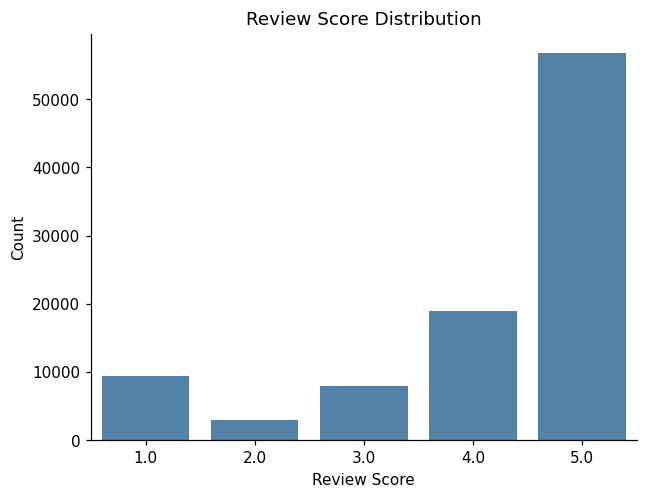

In [ ]:
plt.figure()
sns.countplot(x="review_score", data=df_delivered, color="steelblue")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

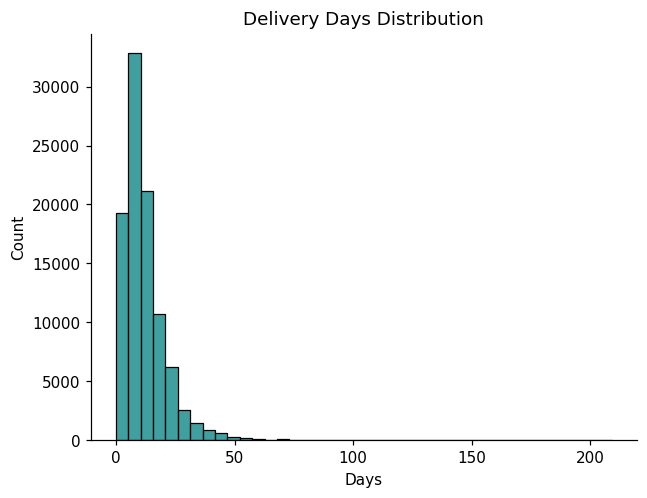

In [ ]:
plt.figure()
sns.histplot(df_delivered["delivery_days"], bins=40, color="teal")
plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

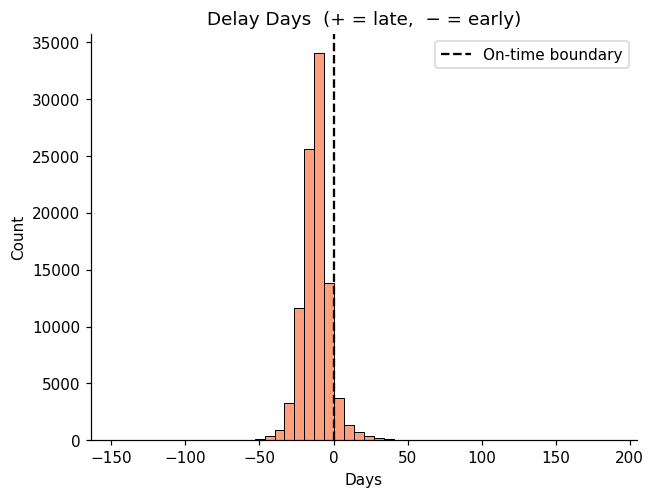

In [ ]:
plt.figure()
sns.histplot(df_delivered["delay_days"], bins=50, color="coral")
plt.axvline(0, color="black", linestyle="--", label="On-time boundary")
plt.title("Delay Days  (+ = late,  − = early)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.legend()
plt.show()

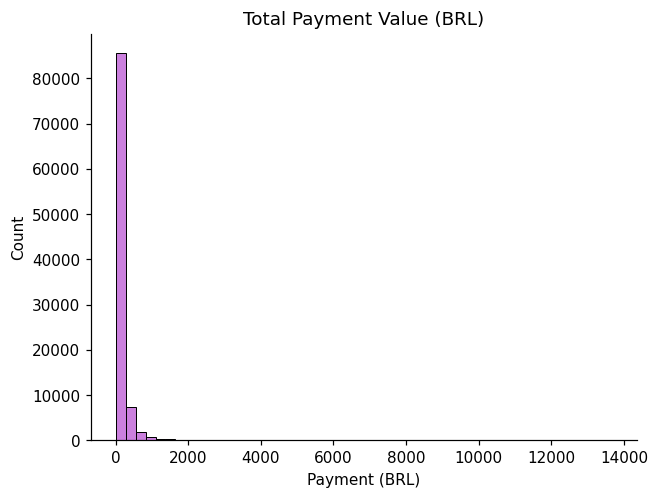

In [ ]:
plt.figure()
sns.histplot(df_delivered["total_payment"], bins=50, color="mediumorchid")
plt.title("Total Payment Value (BRL)")
plt.xlabel("Payment (BRL)")
plt.ylabel("Count")
plt.show()

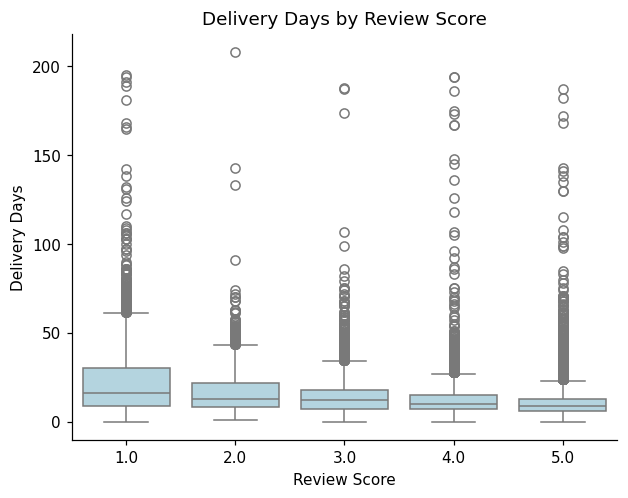

In [ ]:
plt.figure()
sns.boxplot(x="review_score", y="delivery_days", data=df_delivered, color="lightblue")
plt.title("Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.show()

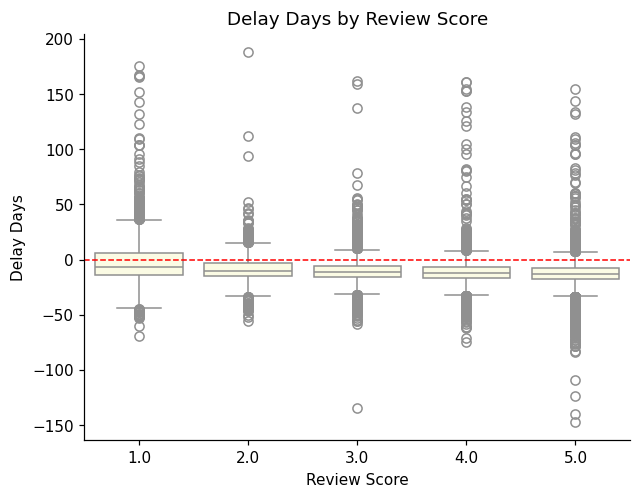

In [ ]:
plt.figure()
sns.boxplot(x="review_score", y="delay_days", data=df_delivered, color="lightyellow")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Delay Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delay Days")
plt.show()

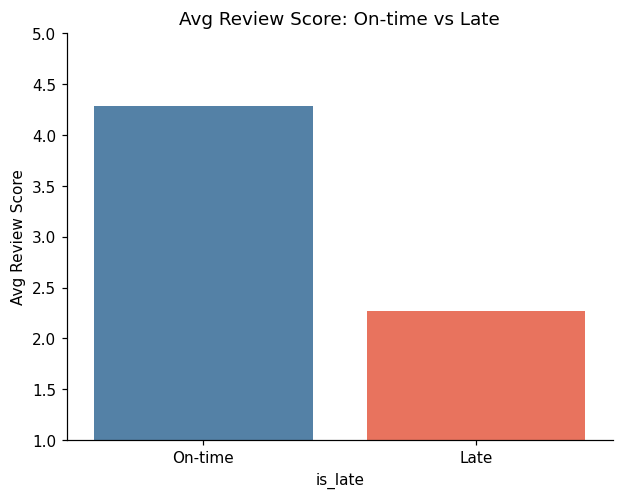

In [ ]:
avg_scores = df_delivered.groupby("is_late")["review_score"].mean().reset_index()
avg_scores["is_late"] = avg_scores["is_late"].map({0: "On-time", 1: "Late"})
plt.figure()
sns.barplot(x="is_late", y="review_score", data=avg_scores, palette=["steelblue", "tomato"])
plt.title("Avg Review Score: On-time vs Late")
plt.ylabel("Avg Review Score")
plt.ylim(1, 5)
plt.show()

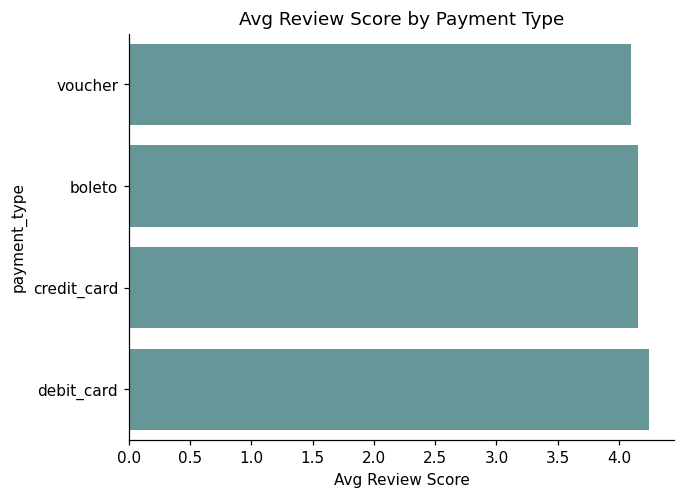

In [ ]:
plt.figure()
sns.barplot(y="payment_type", x="review_score", data=df_delivered,
            color="cadetblue", estimator="mean", errorbar=None)
plt.title("Avg Review Score by Payment Type")
plt.xlabel("Avg Review Score")
plt.show()

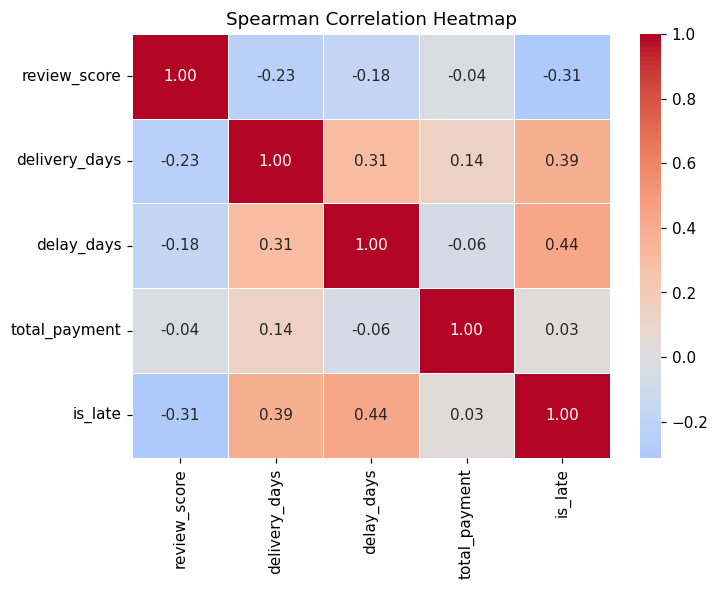

In [ ]:
corr_cols = ["review_score", "delivery_days", "delay_days", "total_payment", "is_late"]
corr_matrix = df_delivered[corr_cols].corr(method="spearman")
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

In [ ]:
late_pct         = df_delivered["is_late"].mean() * 100
avg_score_late   = df_delivered.loc[df_delivered["is_late"]==1, "review_score"].mean()
avg_score_ontime = df_delivered.loc[df_delivered["is_late"]==0, "review_score"].mean()

print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"  Late deliveries     : {late_pct:.1f}% of orders")
print(f"  Avg delivery time   : {df_delivered['delivery_days'].mean():.1f} days")
print(f"  Avg score (on-time) : {avg_score_ontime:.2f}")
print(f"  Avg score (late)    : {avg_score_late:.2f}")
print(f"  Score gap           : {avg_score_late - avg_score_ontime:.2f} stars")
print("=" * 50)

KEY INSIGHTS
  Late deliveries     : 6.8% of orders
  Avg delivery time   : 12.1 days
  Avg score (on-time) : 4.29
  Avg score (late)    : 2.27
  Score gap           : -2.02 stars
